# Visualize the experiment results

In [870]:
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [871]:
print(os.getcwd())

c:\Users\ivadu\Desktop\8.semestrik\vymennik\Prediktivne-riadenie-vymennika-tepla-s-vyuzitim-Koopmanovho-modelu\code\sem2025\data


In [872]:
#relevant = [file for file in os.listdir() if file.endswith('.mat')]
test_data = loadmat('test_data_ident.mat')
train_data = loadmat('train_data_ident.mat')

print(train_data.keys())  
print(test_data.keys())

print(train_data['Utrain'].shape)
print(train_data['Ytrain'].shape)


print(test_data['Utest'].shape)
print(test_data['Ytest'].shape)

dict_keys(['__header__', '__version__', '__globals__', 'Utrain', 'Ytrain'])
dict_keys(['__header__', '__version__', '__globals__', 'Utest', 'Ytest'])
(3251, 1)
(3251, 1)
(2000, 1)
(2000, 1)


In [873]:
""" relevantu = train_sim['U'] = np.vstack((train_sim['U'], test_sim['U']))
relevantx = train_sim['X'] = np.vstack((train_sim['X'], test_sim['X']))


relevantu_train = [file for file in relevantu if '0-5m' in file]
relevantx_train = [file for file in relevantx if '0-5m' in file]

relevantu_test = [file for file in relevantu if '5-5m' in file]
relevantx_test = [file for file in relevantx if '5-5m' in file]
 """

" relevantu = train_sim['U'] = np.vstack((train_sim['U'], test_sim['U']))\nrelevantx = train_sim['X'] = np.vstack((train_sim['X'], test_sim['X']))\n\n\nrelevantu_train = [file for file in relevantu if '0-5m' in file]\nrelevantx_train = [file for file in relevantx if '0-5m' in file]\n\nrelevantu_test = [file for file in relevantu if '5-5m' in file]\nrelevantx_test = [file for file in relevantx if '5-5m' in file]\n "

In [874]:
#sorted(relevantx_test)

In [875]:
# Load the .mat file
#data = loadmat('u50-d10-5m.mat')



In [876]:
#data['uout'][:,0]

In [877]:
""" shift = 0
simu = len(train_data['U']) - shift
 """

u_train = train_data['Utrain'][:,0]


#= np.zeros((simu*len(relevantu_train)))
""" for index, file in enumerate(sorted(relevantu_train)):
    data = loadmat(file)
    u_train[index*simu:index*simu+simu] = data['uout'][shift:,1] """

""" with open('u_train.pkl', 'wb') as file: 
    pickle.dump(u_train, file) """

" with open('u_train.pkl', 'wb') as file: \n    pickle.dump(u_train, file) "

In [878]:
u_train 

array([100, 100, 100, ...,  40,  40,  40], dtype=uint8)

In [879]:

""" shift = 300
simu = len(data['uout']) - shift

u_test = np.zeros((simu*len(relevantu_test)))

for index, file in enumerate(sorted(relevantu_test)):
    data = loadmat(file)
    u_test[index*simu:index*simu+simu] = data['uout'][shift:,1]

with open('u_test.pkl', 'wb') as file:
    pickle.dump(u_test, file) """




u_test = test_data['Utest'][:,0]
u_test

u_test_values = u_test

step_changes = np.where(np.diff(u_test_values) != 0)[0] + 1  # +1 for next index

# Add the first value manually
step_starts = np.insert(step_changes, 0, 0)
step_values = u_test_values[step_starts]

print("Step values in order:", step_values)
print("Step starts at indices:", step_starts)

Step values in order: [100  50  80  30  50  90  40  60]
Step starts at indices: [   0  250  500  750 1000 1250 1500 1750]


In [880]:
# shift = 300
# simu = len(data['uout']) - shift
# u = np.zeros((simu*len(relevantu)))
# for index, file in enumerate(sorted(relevantu)):
#     data = loadmat(file)
#     u[index*simu:index*simu+simu] = data['uout'][shift:,1]

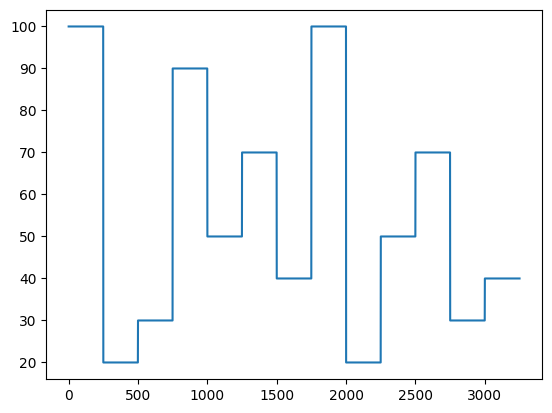

In [881]:
plt.plot(u_train)


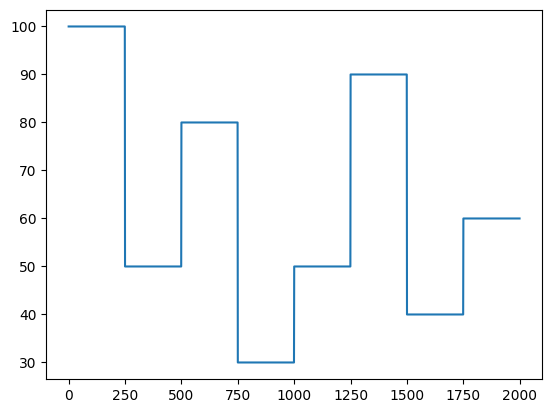

In [882]:
plt.plot(u_test)

In [883]:
""" data = loadmat('T50-d10-5m_T4.mat')
data['T4'][:,0] """

" data = loadmat('T50-d10-5m_T4.mat')\ndata['T4'][:,0] "

In [884]:

train_data['Ytrain'][:,0]

array([60.55718475, 60.55718475, 60.41055718, ..., 53.66568915,
       53.51906158, 53.37243402])

In [885]:
""" simx = len(data['T4']) - shift
x_train = np.zeros((simx*len(relevantx_train)))
for index, file in enumerate(sorted(relevantx_train)):
    data = loadmat(file)
    x_train[index*simx:index*simx+simx] = data['T4'][shift:,0]
    
with open('x_train.pkl', 'wb') as file:
    pickle.dump(x_train, file) """
    
x_train = train_data['Ytrain'][:,0]
x_train

array([60.55718475, 60.55718475, 60.41055718, ..., 53.66568915,
       53.51906158, 53.37243402])

In [886]:
""" simx = len(data['T4']) - shift
x_test = np.zeros((simx*len(relevantx_test)))
for index, file in enumerate(sorted(relevantx_test)):
    data = loadmat(file)
    x_test[index*simx:index*simx+simx] = data['T4'][shift:,0]
    
with open('x_test.pkl', 'wb') as saaaile:
    pickle.dump(x_test, file) """
    
x_test = test_data['Ytest'][:,0]
x_test 

array([57.3313783 , 57.62463343, 57.771261  , ..., 64.07624633,
       63.92961877, 64.2228739 ])

In [887]:
x_train.reshape(-1,1)

array([[60.55718475],
       [60.55718475],
       [60.41055718],
       ...,
       [53.66568915],
       [53.51906158],
       [53.37243402]])

In [888]:
train_real = {'Y': x_train.reshape(-1,1), 'U': u_train.reshape(-1,1)}
test_real = {'Y': x_test.reshape(-1,1), 'U': u_test.reshape(-1,1)}

with open('train_real.pkl', 'wb') as file:
    pickle.dump(train_real, file)
    
with open('test_real.pkl', 'wb') as file:
    pickle.dump(test_real, file)

In [889]:
train_real = pickle.load(open('train_real.pkl', 'rb'))

test_real = pickle.load(open('test_real.pkl', 'rb'))
train_real


{'Y': array([[60.55718475],
        [60.55718475],
        [60.41055718],
        ...,
        [53.66568915],
        [53.51906158],
        [53.37243402]]),
 'U': array([[100],
        [100],
        [100],
        ...,
        [ 40],
        [ 40],
        [ 40]], dtype=uint8)}

In [890]:
test_real

{'Y': array([[57.3313783 ],
        [57.62463343],
        [57.771261  ],
        ...,
        [64.07624633],
        [63.92961877],
        [64.2228739 ]]),
 'U': array([[100],
        [100],
        [100],
        ...,
        [ 60],
        [ 60],
        [ 60]], dtype=uint8)}

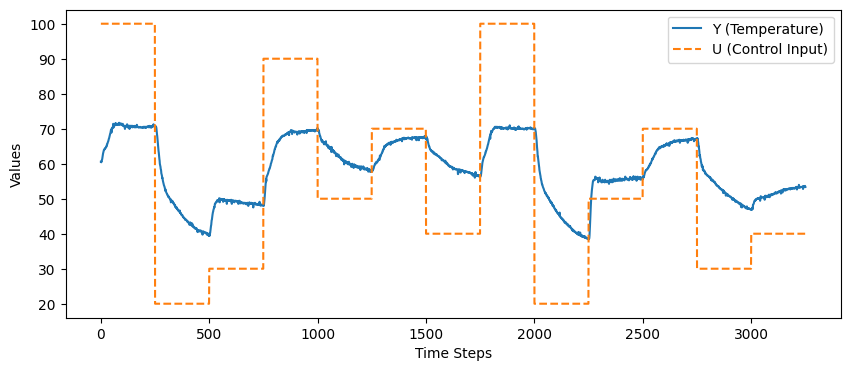

In [891]:
""" plt.plot(train_real) """

plt.figure(figsize=(10,4))
plt.plot(x_train, label='Y (Temperature)')
plt.plot(u_train, label='U (Control Input)', linestyle='dashed')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.show()

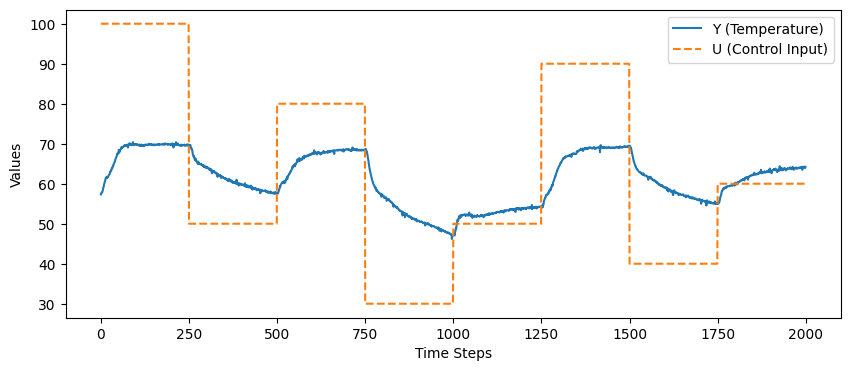

In [892]:
plt.figure(figsize=(10,4))
plt.plot(x_test, label='Y (Temperature)')
plt.plot(u_test, label='U (Control Input)', linestyle='dashed')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.show()

In [893]:
""" simx = len(data['T4']) - shift
x = np.zeros((simx*len(relevantx)))
for index, file in enumerate(sorted(relevantx)):
    data = loadmat(file)
    x[index*simx:index*simx+simx] = data['T4'][shift:,0]
     """


    

" simx = len(data['T4']) - shift\nx = np.zeros((simx*len(relevantx)))\nfor index, file in enumerate(sorted(relevantx)):\n    data = loadmat(file)\n    x[index*simx:index*simx+simx] = data['T4'][shift:,0]\n     "

In [894]:
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

# Merge all data for consistent scaling
x_all = np.concatenate((x_train, x_test)).reshape(-1, 1)
u_all = np.concatenate((u_train, u_test)).reshape(-1, 1)

# Fit new scalers on full data
scaler = StandardScaler().fit(x_all)
scalerU = StandardScaler().fit(u_all)


# Confirm means and stds
print("New scaler mean (x):", scaler.mean_[0])
print("New scaler std (x):", scaler.scale_[0])
print("New scaler mean (u):", scalerU.mean_[0])
print("New scaler std (u):", scalerU.scale_[0])

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(scalerU, 'scalerU.pkl')

# Load scalers
""" scaler = joblib.load('scaler.pkl')
scalerU = joblib.load('scalerU.pkl') """



New scaler mean (x): 59.39946643314973
New scaler std (x): 8.287207401433005
New scaler mean (u): 57.61569224909541
New scaler std (u): 26.348775010882658


" scaler = joblib.load('scaler.pkl')\nscalerU = joblib.load('scalerU.pkl') "

In [895]:
u_all

array([[100],
       [100],
       [100],
       ...,
       [ 60],
       [ 60],
       [ 60]], dtype=uint8)

In [896]:
print("Scaler mean:", scalerU.mean_[0])
print("Scaler std (scale_):", scalerU.scale_)


Scaler mean: 57.61569224909541
Scaler std (scale_): [26.34877501]


In [897]:
def extract_normalized_steps(u_raw, x_raw, step_size=250, delay=100, threshold=0.01, initial_ref=50, label=""):
    u_scaled = scalerU.transform(u_raw.reshape(-1, 1))
    x_scaled = scaler.transform(x_raw.reshape(-1, 1))

    delta_u = np.diff(u_scaled.flatten(), prepend=u_scaled[0])
    step_starts = np.where(np.abs(delta_u) > threshold)[0]

    if step_starts[0] == 0:
        step_starts = step_starts[1:]

    ident_data = []
    step_info = []
    dif = scalerU.transform(np.array([[initial_ref]]))  # reset for each call

    print(f"\n--- {label.upper()} STEP INFO ---")
    for idx in step_starts:
        if idx + step_size > len(u_scaled):
            print(f"Skipping step at t = {idx}: not enough samples for full step window.")
            continue

        delta = u_scaled[idx + delay] - dif
        if delta == 0:
            continue
        normx = (x_scaled[idx:idx + step_size] - x_scaled[idx]) / delta
        ident_data.append(normx.flatten())

        u_unscaled_before = scalerU.inverse_transform(dif.reshape(1, -1)).flatten()[0]
        u_unscaled_after = scalerU.inverse_transform(u_scaled[idx + delay].reshape(1, -1)).flatten()[0]
        delta_unscaled = u_unscaled_after - u_unscaled_before

        print(f"Step at t = {idx}: u changed from {u_unscaled_before:.1f} to {u_unscaled_after:.1f} (Δu = {delta_unscaled:.1f}), delta = {delta.flatten()[0]:.1f}")

        step_info.append({
            "index": idx,
            "u_before": u_unscaled_before,
            "u_after": u_unscaled_after,
            "delta_u": delta_unscaled
        })

        dif = u_scaled[idx + delay]

    return np.array(ident_data), step_starts, step_info



In [898]:
print(type(scalerU))
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>
<class 'sklearn.preprocessing._data.StandardScaler'>


In [899]:
print(u_all.shape)
print(u_all[:])

(5251, 1)
[[100]
 [100]
 [100]
 ...
 [ 60]
 [ 60]
 [ 60]]


In [900]:
train_steps, train_indices, train_info = extract_normalized_steps(
    u_train, x_train, step_size=250, label="train", initial_ref=u_train[0]
)

test_steps, test_indices, test_info = extract_normalized_steps(
    u_test, x_test, step_size=250, label="test", initial_ref=u_test[0]
)
# Combine if needed
all_ident_data = np.vstack((train_steps, test_steps)) #iba x


--- TRAIN STEP INFO ---
Step at t = 250: u changed from 100.0 to 20.0 (Δu = -80.0), delta = -3.0
Step at t = 500: u changed from 20.0 to 30.0 (Δu = 10.0), delta = 0.4
Step at t = 750: u changed from 30.0 to 90.0 (Δu = 60.0), delta = 2.3
Step at t = 1000: u changed from 90.0 to 50.0 (Δu = -40.0), delta = -1.5
Step at t = 1250: u changed from 50.0 to 70.0 (Δu = 20.0), delta = 0.8
Step at t = 1500: u changed from 70.0 to 40.0 (Δu = -30.0), delta = -1.1
Step at t = 1750: u changed from 40.0 to 100.0 (Δu = 60.0), delta = 2.3
Step at t = 2000: u changed from 100.0 to 20.0 (Δu = -80.0), delta = -3.0
Step at t = 2250: u changed from 20.0 to 50.0 (Δu = 30.0), delta = 1.1
Step at t = 2500: u changed from 50.0 to 70.0 (Δu = 20.0), delta = 0.8
Step at t = 2750: u changed from 70.0 to 30.0 (Δu = -40.0), delta = -1.5
Step at t = 3000: u changed from 30.0 to 40.0 (Δu = 10.0), delta = 0.4

--- TEST STEP INFO ---
Step at t = 250: u changed from 100.0 to 50.0 (Δu = -50.0), delta = -1.9
Step at t = 500:

In [901]:
train_steps

array([[-0.        , -0.        , -0.        , ...,  1.24124486,
         1.23541742,  1.24124486],
       [ 0.        ,  0.04661953, -0.04661953, ...,  2.70393246,
         2.70393246,  2.70393246],
       [ 0.        , -0.00776992,  0.        , ...,  1.14217837,
         1.13440845,  1.17325805],
       ...,
       [ 0.        ,  0.13985858,  0.11654881, ...,  1.84147125,
         1.81816148,  1.84147125],
       [-0.        ,  0.01165488, -0.01165488, ...,  1.60837362,
         1.60837362,  1.60837362],
       [ 0.        , -0.04661953,  0.        , ...,  2.05125911,
         2.14449816,  2.09787864]])

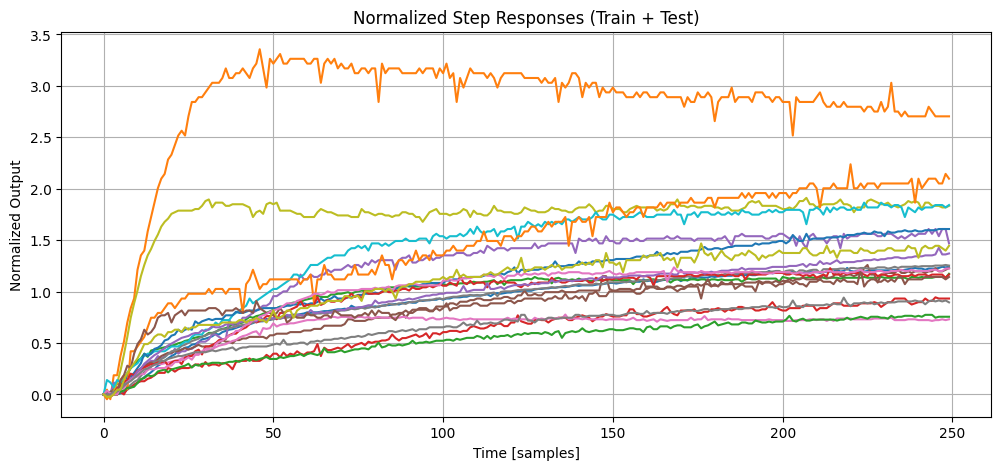

Total valid steps: 19


In [902]:
plt.figure(figsize=(12, 5))
for row in all_ident_data:
    plt.plot(row)
plt.title('Normalized Step Responses (Train + Test)')
plt.xlabel('Time [samples]')
plt.ylabel('Normalized Output')
plt.grid(True)
plt.show()

print(f"Total valid steps: {all_ident_data.shape[0]}")


In [903]:
print(all_ident_data.shape)
print(all_ident_data[:5])

(19, 250)
[[-0.         -0.         -0.         ...  1.24124486  1.23541742
   1.24124486]
 [ 0.          0.04661953 -0.04661953 ...  2.70393246  2.70393246
   2.70393246]
 [ 0.         -0.00776992  0.         ...  1.14217837  1.13440845
   1.17325805]
 [-0.         -0.01165488 -0.02330976 ...  0.9323905   0.9323905
   0.9323905 ]
 [ 0.          0.          0.         ...  1.60837362  1.60837362
   1.46851505]]


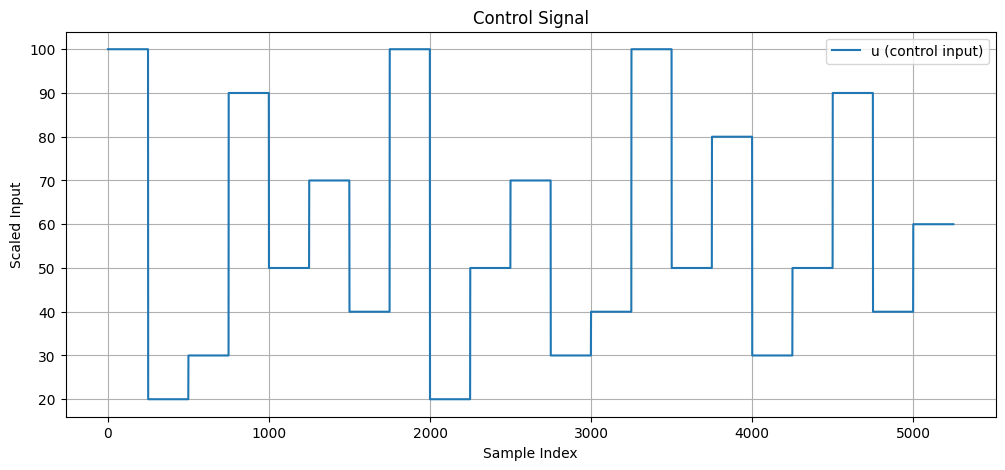

In [904]:
# Plot control signal and its difference
u_flat = u_all.flatten()
delta_u = np.diff(u_flat, prepend=u_flat[0])

plt.figure(figsize=(12, 5))
plt.plot(u_flat, label='u (control input)')
""" plt.plot(delta_u, label='Δu (difference)', linestyle='dashed') """
plt.title('Control Signal')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Input')
plt.grid(True)
plt.legend()
plt.show()

In [905]:
len(x_train)/250

13.004

In [906]:
all_ident_data.shape
all_ident_data

array([[-0.        , -0.        , -0.        , ...,  1.24124486,
         1.23541742,  1.24124486],
       [ 0.        ,  0.04661953, -0.04661953, ...,  2.70393246,
         2.70393246,  2.70393246],
       [ 0.        , -0.00776992,  0.        , ...,  1.14217837,
         1.13440845,  1.17325805],
       ...,
       [ 0.        ,  0.03496464,  0.01165488, ...,  1.20045278,
         1.22376254,  1.22376254],
       [-0.        , -0.        , -0.        , ...,  0.90441879,
         0.91374269,  0.89509488],
       [ 0.        , -0.02330976, -0.02330976, ...,  1.42189552,
         1.39858576,  1.44520528]])

Steady-state gain K ≈ 1.3707
Time constant (τ) ≈ 43 samples


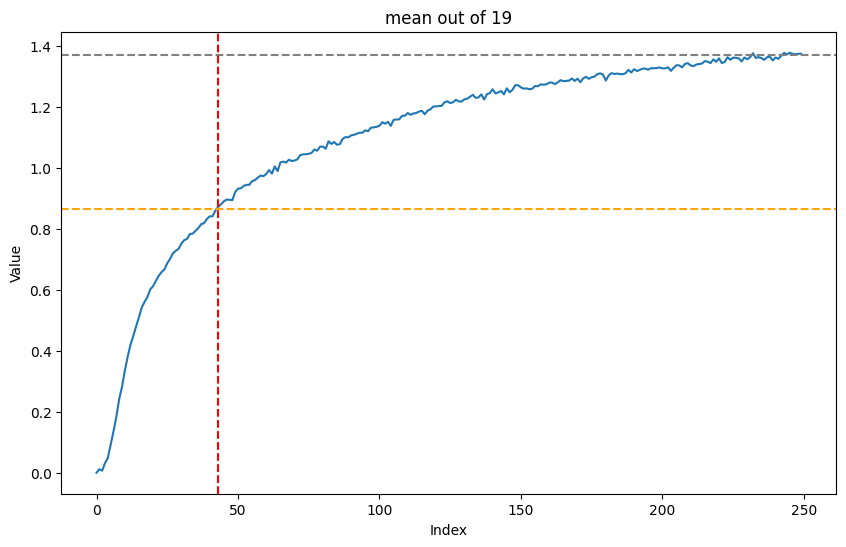

In [907]:
mean_row = np.mean(all_ident_data, axis=0)
K = np.mean(mean_row[-10:])
target_value = 0.632 * K

#time constant idx
time_constant_idx = np.where(mean_row >= target_value)[0][0]


print(f"Steady-state gain K ≈ {K:.4f}")
print(f"Time constant (τ) ≈ {time_constant_idx} samples")


plt.figure(figsize=(10, 6))

plt.plot(mean_row)
plt.axhline(K, linestyle='--', color='gray', label='Steady State K')
plt.axhline(target_value, linestyle='--', color='orange', label='63.2% of K')
plt.axvline(time_constant_idx, linestyle='--', color='red', label='τ')

plt.xlabel('Index')
plt.ylabel('Value')
plt.title('mean out of 19')
plt.show()

In [908]:
print("Python scaler mean (x):", scaler.mean_[0])
print("Python scaler std (x):", scaler.scale_[0])

print("Python scaler mean (u):", scalerU.mean_[0])
print("Python scaler std (u):", scalerU.scale_[0])


Python scaler mean (x): 59.39946643314973
Python scaler std (x): 8.287207401433005
Python scaler mean (u): 57.61569224909541
Python scaler std (u): 26.348775010882658
